In [2]:
here::i_am("rna/mapping/run/mnn/mapping_mnn.R")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

# Load packages
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(batchelor))

######################
## Define arguments ##
######################

# p <- ArgumentParser(description='')
# p$add_argument('--atlas_stages',    type="character",   nargs='+',  help='Atlas stage(s)')
# p$add_argument('--query_samples',   type="character",   nargs='+',  help='Query batch(es)')
# p$add_argument('--query_sce',       type="character",               help='SingleCellExperiment file for the query')
# p$add_argument('--atlas_sce',       type="character",               help='SingleCellExperiment file for the atlas')
# p$add_argument('--query_metadata',  type="character",               help='metadata file for the query')
# p$add_argument('--atlas_metadata',  type="character",               help='metadata file for the atlas')
# p$add_argument('--npcs',            type="integer",                 help='Number of principal components')
# p$add_argument('--n_neighbours',    type="integer",                 help='Number of neighbours')
# p$add_argument('--use_marker_genes',action = "store_true",          help='Use marker genes?')
# p$add_argument('--cosine_normalisation',      action = "store_true",          help='Use cosine normalisation?')
# p$add_argument('--test',            action = "store_true",          help='Testing mode')
# p$add_argument('--outfile',          type="character",               help='Output file')
# args <- p$parse_args(commandArgs(TRUE))

# #####################
## Define settings ##
#####################

# I/O
io$path2atlas <- io$atlas.basedir
io$path2query <- io$basedir


# Load mapping functions
source(here::here("rna/mapping/run/mnn/mapping_functions.R"))


## START TEST ##
args = list()
args$atlas_stages <- c("E6.5","E6.75","E7.0","E7.25","E7.5","E7.75","E8.0","E8.25","E8.5")
args$query_samples <- opts$samples
args$query_sce <- io$rna.sce
args$query_sce <- paste0(io$basedir,"/processed/rna/SingleCellExperiment.rds")
args$atlas_sce <- io$rna.atlas.sce
args$query_metadata <- file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$atlas_metadata <- io$rna.atlas.metadata
args$test <- FALSE
args$npcs <- 50
args$n_neighbours <- 25
args$use_marker_genes <- FALSE
args$cosine_normalisation <- FALSE
args$outfile <- paste0(io$basedir,"/results/rna/mapping/test/TEEEEST")
## END TEST ##

if (isTRUE(args$test)) print("Test mode activated...")


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [3]:

################
## Load query ##
################

# Load cell metadata
meta_query <- fread(args$query_metadata) %>% 
  .[pass_rnaQC==TRUE & doublet_call==FALSE & sample%in%args$query_samples]
if (isTRUE(args$test)) meta_query <- head(meta_query,n=1000)

# Load SingleCellExperiment
sce_query <- load_SingleCellExperiment(args$query_sce, cells = meta_query$cell, remove_non_expressed_genes = TRUE)

# Update colData
tmp <- meta_query %>% .[cell%in%colnames(sce_query)] %>% setkey(cell) %>% .[colnames(sce_query)]
stopifnot(tmp$cell == colnames(sce_query))
colData(sce_query) <- tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce_query),] %>% DataFrame()

In [4]:
################
## Load atlas ##
################

# Load cell metadata
meta_atlas <- fread(args$atlas_metadata) %>%
  .[stripped==F & doublet==F & stage%in%args$atlas_stages] %>%
  .[,sample:=factor(sample)]

# Filter
if (isTRUE(args$test)) meta_atlas <- head(meta_atlas,n=38346)

# Load SingleCellExperiment
sce_atlas <- load_SingleCellExperiment(args$atlas_sce, normalise = TRUE, cells = meta_atlas$cell, remove_non_expressed_genes = TRUE)

# Update colData
tmp <- meta_atlas %>% .[cell%in%colnames(sce_atlas)] %>% setkey(cell) %>% .[colnames(sce_atlas)]
stopifnot(tmp$cell == colnames(sce_atlas))
colData(sce_atlas) <- tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce_atlas),] %>% DataFrame()


In [5]:
sce_atlas
sce_query

class: SingleCellExperiment 
dim: 19379 108857 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(19379): ENSMUSG00000051951 ENSMUSG00000025900 ...
  ENSMUSG00000063897 ENSMUSG00000095742
rowData names(0):
colnames(108857): cell_1 cell_10 ... cell_99998 cell_99999
colData names(11): barcode sample ... nFeature_RNA nCount_RNA
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

class: SingleCellExperiment 
dim: 22963 35125 
metadata(0):
assays(1): counts
rownames(22963): Xkr4 Gm1992 ... CAAA01147332.1 AC149090.1
rowData names(0):
colnames(35125): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(22): barcode sample ... celltype_genotype
  celltype_extended_genotype
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [6]:
#############
## Prepare ## 
#############

# Rename ensemble IDs to gene names in the atlas
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id%in%rownames(sce_atlas)] %>%
  .[!duplicated(symbol)]

sce_atlas <- sce_atlas[rownames(sce_atlas)%in%gene_metadata$ens_id,]
foo <- gene_metadata$symbol; names(foo) <- gene_metadata$ens_id
rownames(sce_atlas) <- foo[rownames(sce_atlas)]

# Sanity checks
stopifnot(sum(is.na(rownames(sce_atlas)))==0)
stopifnot(sum(duplicated(rownames(sce_atlas)))==0)

stopifnot(TRUE %in% (meta_query$cell %in% meta_atlas$cell)==FALSE)

In [7]:
#####################
## Define gene set ##
#####################

# Intersect genes
genes.intersect <- intersect(rownames(sce_query), rownames(sce_atlas))

# Filter some genes manually
genes.intersect <- genes.intersect[grep("^Rik|Rik$|^mt-|^Rps-|^Rpl-|^Gm",genes.intersect,invert=T)]
genes.intersect <- genes.intersect[!genes.intersect=="Xist"]
genes.intersect <- genes.intersect[!genes.intersect%in%gene_metadata[chr=="chrY",symbol]]

# Subset SingleCellExperiment objects
sce_query  <- sce_query[genes.intersect,]
sce_atlas <- sce_atlas[genes.intersect,]

In [11]:
sce_atlas
sce_query

class: SingleCellExperiment 
dim: 15398 108857 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(15398): Xkr4 Rp1 ... Hccs Mid1
rowData names(0):
colnames(108857): cell_1 cell_10 ... cell_99998 cell_99999
colData names(11): barcode sample ... nFeature_RNA nCount_RNA
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

class: SingleCellExperiment 
dim: 15398 35125 
metadata(0):
assays(1): counts
rownames(15398): Xkr4 Rp1 ... Hccs Mid1
rowData names(0):
colnames(35125): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(22): barcode sample ... celltype_genotype
  celltype_extended_genotype
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [9]:
#######################
## Feature selection ##
#######################

if (args$use_marker_genes) {
  # Load marker genes
  marker_genes.dt <- fread(io$rna.atlas.marker_genes)
  genes_to_use <- genes.intersect[genes.intersect%in%unique(marker_genes.dt$gene)]
} else {
  # Load gene statistics from the atlas
  gene_stats.dt <- fread(paste0(io$atlas.basedir,"/results/gene_statistics/gene_statistics.txt.gz")) %>%
    .[gene%in%genes.intersect]
  genes_to_use <- gene_stats.dt %>% setorder(-var_pseudobulk, na.last = T) %>% head(n=2500) %>% .$gene  
  
  # Calculate mean-variance relationship and extract HVGs
  # decomp <- modelGeneVar(sce_atlas, block=sce_atlas$sample)
  # genes_to_use <- rownames(decomp)[decomp$p.value<=0.01 & decomp$mean>0.1]
}

stopifnot(genes_to_use%in%rownames(sce_atlas))
stopifnot(genes_to_use%in%rownames(sce_query))


In [10]:
sce_atlas_bu = sce_atlas
sce_query_bu = sce_query

In [12]:
#########
## Map ##
#########

# TO-DO: TRY COSINE NORMALISATION
mapping  <- mapWrap(
  sce_atlas = sce_atlas,
  meta_atlas = meta_atlas,
  sce_query = sce_query,
  meta_query = meta_query,
  genes = genes_to_use ,  # genes_to_use
  npcs = args$npcs, 
  k = args$n_neighbours,
  cosineNorm = args$cosine_normalisation,
  order = NULL
)

Normalizing joint dataset using cosineNorm=FALSE...

Done


2500 Genes provided...

Performing PCA...

Done


Batch effect correction for the atlas...

Loading required package: BiocParallel

Done


MNN mapping...

Done


Computing mapping scores...

Done


Writing output...

Done




In [15]:
head(mapping$pca_atlas_corrected)

cell_1,13.51881,-5.806711,-2.0963761,-2.1532819,2.753873,3.467404,2.630101,2.9638691,-1.0175341,-0.5314404,⋯,-0.07177343,0.3358949,1.1096713,1.8352360,-0.92841444,-0.4582272,1.923713,-0.4808405,-0.2218293,1.827749
cell_10,13.31978,-5.599048,-0.1673792,-3.2458306,2.454581,3.620958,2.786619,2.8669333,-0.3314610,-0.3071027,⋯,-1.00087467,-1.2012296,0.9471623,1.5667806,-0.18049132,-0.8948212,2.646413,-0.9469735,-0.5251681,2.243552
cell_100,13.76419,-5.103983,-0.9157646,-1.4119081,3.644527,3.953056,3.145124,2.7577613,-0.8719565,-0.8929744,⋯,-0.37578658,-0.1514781,0.8999465,0.3995531,-0.69402324,-0.6172634,1.491045,-0.5128588,-0.6024151,2.265111
cell_1000,11.46627,-5.959751,-1.2891872,0.3351130,-1.680999,2.697301,-1.787829,2.0223410,0.7320739,2.2100933,⋯,-0.97920704,1.2968610,1.9006720,0.4747022,0.05702193,-1.9641358,0.931300,-1.0856976,-0.7039616,2.418876
cell_10000,13.75466,-4.343748,-1.0894600,-0.3886343,1.847133,4.485001,2.038408,2.2253309,-1.1837095,1.1991948,⋯,-0.46557401,1.7338974,0.1331250,1.7438405,-1.35030769,-0.3628370,1.244598,-0.3207038,-0.5117297,1.163933
cell_100000,11.53949,-2.795933,-5.1056565,1.4358713,-2.840608,2.055651,-2.360686,0.3831568,-0.5592646,2.8846847,⋯,-0.30354649,0.5476347,0.9111558,0.1257496,-0.52112913,-0.4346214,2.410462,-2.0728230,-0.8946313,1.324386


In [17]:
umap = uwot::umap(rbind(mapping$pca_query_corrected, mapping$pca_atlas_corrected), n_neighbors=25, min_dist = 0.3)

In [18]:
umap.dt = as.data.table(umap, keep.rownames = T) %>%
    .[, group := c(rep('

In [20]:
head(umap.dt)

rn,V1,V2
<chr>,<dbl>,<dbl>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,-4.511544,2.128819
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,-5.837668,1.072600
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,-4.726779,2.068058
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,-5.904804,1.494297
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,-4.440799,1.699542
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,-5.990856,1.175475


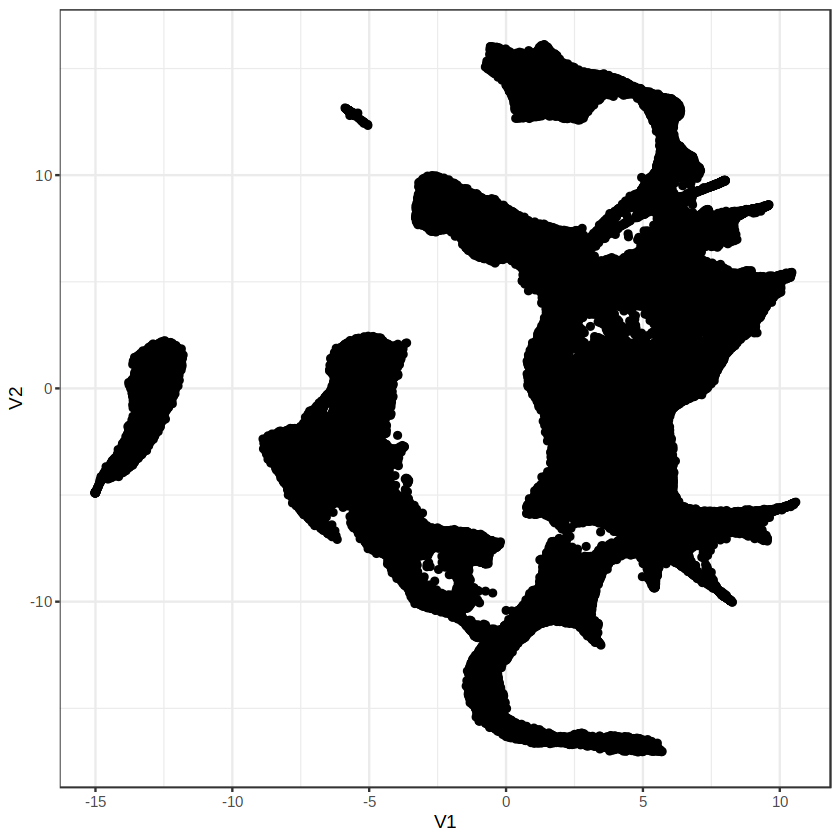

In [19]:
ggplot(umap.dt, aes(V1, V2)) + 
    geom_point() + 
    theme_bw()

In [105]:
dir.create('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/mapping/test/')

In [187]:



##########
## Save ##
##########

mapping.dt <- mapping$mapping %>% 
  .[,c("cell","celltype.mapped","celltype.score","closest.cell")] %>% 
  setnames("celltype.mapped","celltype") %>%
  as.data.table

# outfile <- sprintf("%s/mapping_mnn_%s.txt.gz",args$outdir,paste(args$query_samples,collapse="-"))
# fwrite(mapping.dt, outfile, sep="\t")
fwrite(mapping.dt, args$outfile, sep="\t")

##########
## TEST ##
##########

# previous_mapping.dt <- fread("/Users/argelagr/data/gastrulation_histones/results/rna/mapping/old/sample_metadata_after_mapping.txt.gz") %>%
#   .[,c("cell","celltype.mapped_mnn","celltype.mapped_seurat")] %>% setnames(c("cell","old_mapping_mnn","old_mapping_seurat"))
# foo <- merge(previous_mapping.dt, mapping.dt[,c("cell","celltype.mapped")], by="cell")
# 

In [188]:
big_meta = rbind(meta_query[,c('cell', 'sample')][,origin:='query'] %>% 
                     merge(mapping.dt[,c('cell','celltype')],
                           by='cell'), 
                 meta_atlas[,c('cell', 'sample', 'celltype')][,origin:='atlas']) %>%
            merge(meta_atlas[,c('cell', 'stage')], all=TRUE)

#fwrite(big_meta, gsub('.txt.gz', '_bigmeta.txt.gz', args$outfile), sep="\t")

big_pca = as.data.table(mapping$pca, keep.rownames=T) %>% setnames('rn', 'cell') %>% .[order(match(cell, big_meta$cell)),]
#fwrite(big_pca, gsub('.txt.gz', '_bigPCA.txt.gz', args$outfile), sep="\t")


In [189]:
library(uwot)

In [190]:
umap = umap(big_pca, n_neighbors=25, min_dist = 0.3)

In [191]:
to.plot = cbind(big_meta, umap)

In [192]:
library(patchwork)

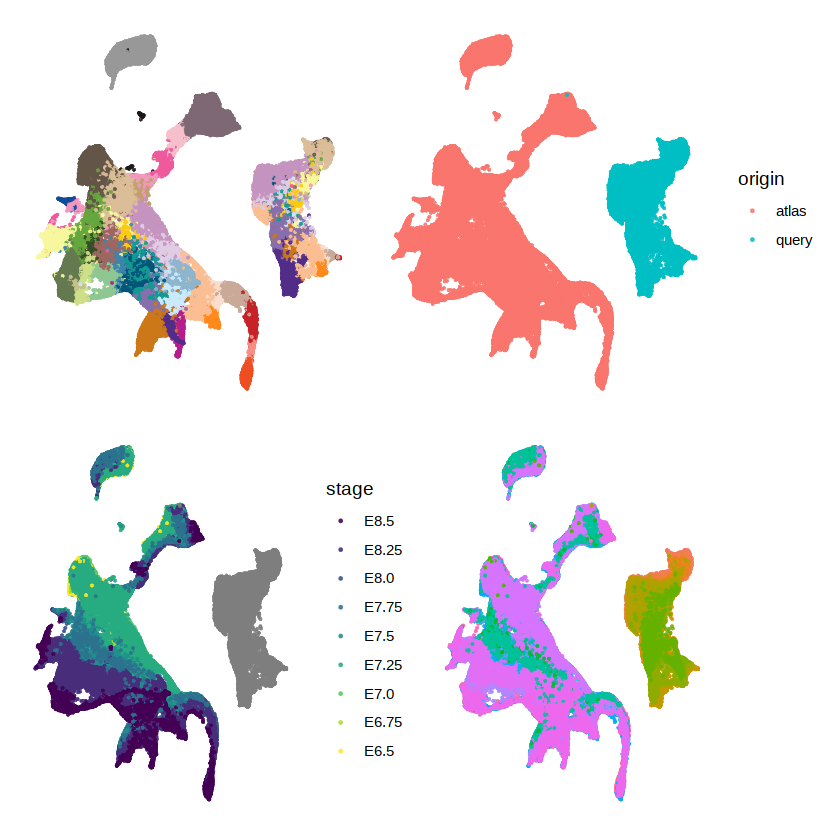

In [193]:
p1 = ggplot(to.plot, aes_string(x="V1", y="V2", col='celltype')) +
    ggrastr::rasterise(geom_point(size=0.3, alpha = 0.8), dpi=400) +
    theme_classic() +
    ggplot_theme_NoAxes() + scale_color_manual(values=opts$celltype.colors) +
      theme(
        legend.position="none",
        legend.title=element_blank()
      )

p2 = ggplot(to.plot, aes_string(x="V1", y="V2", col='origin')) +
    ggrastr::rasterise(geom_point(size=0.3, alpha = 0.8), dpi=400) +
    theme_classic() +
    ggplot_theme_NoAxes()

p3 = ggplot(to.plot, aes_string(x="V1", y="V2", col='stage')) +
    ggrastr::rasterise(geom_point(size=0.3, alpha = 0.8), dpi=400) +
    theme_classic() +
    ggplot_theme_NoAxes() + scale_color_manual(values=opts$stage.colors)

p4 = ggplot(to.plot, aes_string(x="V1", y="V2", col='sample')) +
    ggrastr::rasterise(geom_point(size=0.3, alpha = 0.8), dpi=400) +
    theme_classic() +
    ggplot_theme_NoAxes() +       
    theme(
        legend.position="none",
        legend.title=element_blank()
      )

(p1 + p2) / (p3 + p4)

In [194]:
pdf(file = gsub('.txt.gz', '_umap.pdf', args$outfile), height = 8, width = 15)
    (p1 + p2) / (p3 + p4)
dev.off()

png 
  2

In [139]:
head(big_meta[origin=='query'])

cell,sample,origin,celltype
<chr>,<fct>,<chr>,<chr>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,query,Forebrain_Midbrain_Hindbrain
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,query,Nascent_mesoderm
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,query,Epiblast
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,1A_Eo_DEG_G9_day3,query,Nascent_mesoderm
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,1A_Eo_DEG_G9_day3,query,Spinal_cord
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,1A_Eo_DEG_G9_day3,query,Surface_ectoderm


In [140]:
umap = umap(big_pca[cell %in% big_meta[origin=='query']$cell], n_neighbors=25, min_dist = 0.3)

In [141]:
to.plot = cbind(big_meta[origin=='query'], umap)

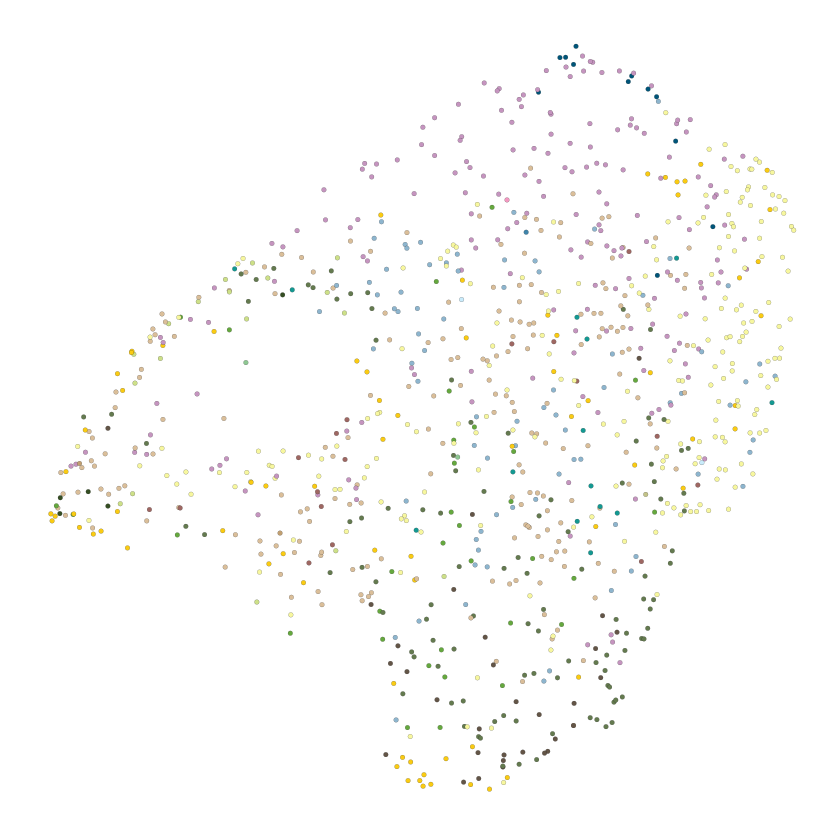

In [142]:
ggplot(to.plot, aes_string(x="V1", y="V2", fill='celltype')) +
    geom_point(size=1, shape=21, stroke=0.05) +
    theme_classic() +
    ggplot_theme_NoAxes() + scale_fill_manual(values=opts$celltype.colors) +
      theme(
        legend.position="none",
        legend.title=element_blank()
      )

In [120]:
summary(big_meta$cell == big_pca$cell)

   Mode    TRUE 
logical   39346 

In [119]:
tail(big_meta)

cell,sample,origin,celltype
<chr>,<fct>,<chr>,<chr>
cell_16576,12,atlas,Mesenchyme
cell_16577,12,atlas,ExE_mesoderm
cell_16579,12,atlas,ExE_endoderm
cell_1658,5,atlas,Epiblast
cell_16580,12,atlas,Rostral_neurectoderm
cell_16581,12,atlas,ExE_ectoderm


In [117]:
big_pca[order(match(cell, big_meta$cell)),]

cell,V1,V2,V3,V4,V5,V6,V7,V8,V9,⋯,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,-12.344975,1.1933847,-0.0003899476,-3.0633681,1.2242239,-5.49543050,0.55191173,2.2277922,0.0331026,⋯,-0.9851168,-2.11760332,-2.3496241,-0.54613100,1.0641534,0.03865801,0.5630769,1.1712245,0.6002618,-0.61407052
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,-15.706819,2.2266678,-1.5158880189,1.6302446,0.3294257,0.61012327,-0.70036169,-3.0341095,-2.1722660,⋯,-1.4547135,-2.89757063,0.5614836,0.81045112,-2.2187096,0.55121802,-3.1646684,-1.3994663,-1.2768533,0.07370374
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,-9.525168,0.3153552,2.3660119660,-2.6812179,1.0357981,-4.57746773,0.48708096,4.4721221,0.1953783,⋯,1.7883398,2.88434485,0.7510430,-0.10687569,1.7109685,0.94029152,1.0253420,0.3421055,-1.0059567,0.67236117
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,-16.678742,-0.8508183,-0.5106472222,0.8096179,0.5109414,-0.09701736,0.12891874,0.2613066,3.1625985,⋯,1.4084139,2.24687591,0.3732146,-1.29958021,0.3932512,-0.16069562,-1.4244627,0.1084472,2.1844198,-0.60828530
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,-11.029156,0.7543240,2.5761427268,-1.7365652,-1.3616476,-3.05857994,1.07977979,2.7680991,-3.4994644,⋯,-3.4575751,-0.05603672,-1.5888171,-0.08148244,-3.1808507,0.67336989,-3.1469407,-0.8366673,0.3961347,-0.97324816
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,-15.105948,0.5450880,-2.3431300942,-0.4692722,0.6561824,-0.47895963,0.02328588,-2.4801859,-0.9836504,⋯,1.1025611,-2.16210470,1.2528063,-0.26074631,-1.4142245,-0.55292156,0.5729384,-0.6246184,1.4365360,0.57949619


In [111]:
head(fread(gsub('.txt.gz', '_bigmeta.txt.gz', args$outfile)))

cell,sample,origin,celltype
<chr>,<chr>,<chr>,<chr>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,query,Epiblast
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,query,Surface_ectoderm
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,query,Epiblast
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,1A_Eo_DEG_G9_day3,query,Primitive_Streak
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,1A_Eo_DEG_G9_day3,query,Primitive_Streak
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,1A_Eo_DEG_G9_day3,query,Forebrain_Midbrain_Hindbrain


In [91]:
head(big_pca)

cell_1,9.718560,-4.307695,4.4782316,-8.0998749,0.2950373,-1.6431156,-2.0108592,-0.8997206,-0.3870561,-0.5957260,2.20263867,0.58455951,-1.4548594,-0.8536188,2.5839665,0.8355307,-1.6178222,-1.69077130,0.59640731,-1.0102222
cell_10,8.362014,-2.536820,5.4903800,-8.4628887,-0.5338067,-0.6131847,-2.3008214,0.4842363,0.7870469,1.0001147,3.44929181,-0.54757400,-1.1312035,-1.1011199,1.2010990,0.1413115,-0.0773653,-1.40118491,0.40845097,-2.7305998
cell_100,9.893817,-2.946812,4.0808442,-10.3495860,0.2923019,-1.9425644,-2.4740851,-1.7265453,0.1319271,-0.4294601,2.23458997,-1.08900559,-2.0268899,0.4453227,1.2350457,0.8152170,-1.5120147,0.62490852,-0.01333991,-2.3365605
cell_1000,7.352481,-4.941647,-0.6234091,-4.9516029,-1.6458256,3.0321054,1.8575382,-0.8676947,0.3649953,-2.5620874,-1.25570687,2.35665090,0.7008193,2.0201155,-0.2887123,0.4773052,0.1388249,-1.03217195,-0.12636634,1.4604641
cell_10000,9.322015,-3.578052,1.2463524,-8.2985204,-0.5924890,-2.3225159,0.3278987,-2.5129809,1.0211642,0.3729403,1.22880182,-1.13605841,-2.1788825,0.7919934,1.2389334,-0.1967743,-1.3486418,0.06936617,0.42470864,0.5023903
cell_100000,12.774373,-5.063085,-3.2048539,0.9172205,-1.4279633,-1.7845974,3.0871130,-2.9543041,-1.4162385,3.6259016,0.05596637,-0.07898563,1.1760628,-1.7167305,-1.2138651,-0.4828630,0.9076189,0.42828136,-1.24368792,1.0608852


In [100]:
head(meta_query[,c('cell', 'sample')][,origin:='query'] %>% merge(mapping.dt[,c('cell','celltype'),by='cell']))

cell,sample,origin,V1
<chr>,<chr>,<chr>,<chr>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,query,cell
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,query,celltype
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,query,cell
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,query,celltype
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,query,cell
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,query,celltype


In [102]:
head(big_meta)

cell,sample,origin,celltype
<chr>,<fct>,<chr>,<chr>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,query,Epiblast
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,query,Surface_ectoderm
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,query,Epiblast
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,1A_Eo_DEG_G9_day3,query,Primitive_Streak
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,1A_Eo_DEG_G9_day3,query,Primitive_Streak
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,1A_Eo_DEG_G9_day3,query,Forebrain_Midbrain_Hindbrain


In [86]:
args$outfile <- paste0(io$basedir,"/results/rna/mapping/test/mapping.txt.gz")


In [89]:
gsub('.txt.gz', '_bigPCA.txt.gz', args$outfile)

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/mapping/test/mapping_bigPCA.txt.gz"